<a href="https://colab.research.google.com/github/ErnaZekovic/SQL_and_Excel_Analysis/blob/main/Microprocessor_Thermal_ML_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

# Simulate 500 measurements from a microprocessor chip
np.random.seed(42)
voltage = np.random.uniform(1.0, 1.4, 500)       # Core voltage in Volts (V)
frequency = voltage * 3.0 + np.random.normal(0, 0.1, 500) # Clock speed in GHz
# Physical formula for chip temperature based on voltage and frequency
temperature = 30 + (voltage * 20) + (frequency * 10) + np.random.normal(0, 2, 500) # Temperature in °C

# Create a clean DataFrame with English columns
dataset = pd.DataFrame({
    'Voltage_V': voltage,
    'Frequency_GHz': frequency,
    'Temperature_C': temperature
})

print("Dataset successfully generated!")
print(dataset.head()) # Displays the first 5 rows of the dataset

Dataset successfully generated!
   Voltage_V  Frequency_GHz  Temperature_C
0   1.149816       3.483624      89.000415
1   1.380286       4.328474     100.171873
2   1.292798       3.973435      96.771612
3   1.239463       3.660700      93.613673
4   1.062407       3.097381      83.862922


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Define inputs (X) and target variable (y)
X = dataset[['Voltage_V', 'Frequency_GHz']]
y = dataset['Temperature_C']

# Split data: 80% for training the model, 20% for testing performance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
ml_model = LinearRegression()
ml_model.fit(X_train, y_train)

# Generate predictions on the test dataset
predictions = ml_model.predict(X_test)

# Calculate and display the final accuracy score
accuracy_r2 = r2_score(y_test, predictions)
print(f"Model R2 Score (Accuracy): {accuracy_r2:.2f}")

Model R2 Score (Accuracy): 0.92


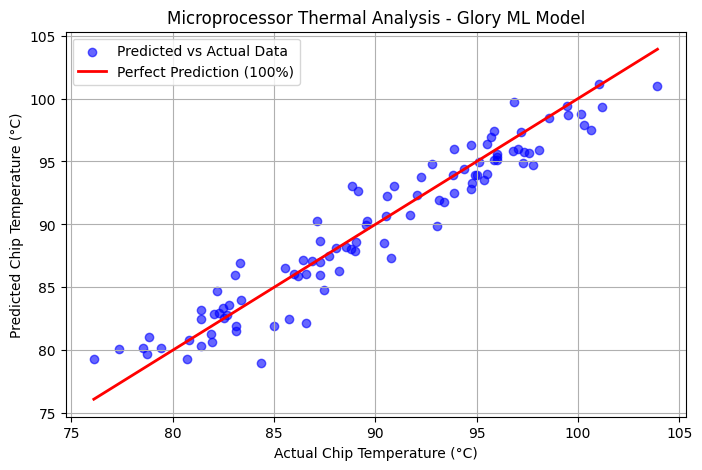

In [ ]:
import matplotlib.pyplot as plt

# Plotting the actual vs predicted data points
plt.figure(figsize=(8, 5))
plt.scatter(y_test, predictions, color='blue', alpha=0.6, label='Predicted vs Actual Data')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, label='Perfect Prediction (100%)')

# Setting labels and title in English for professional evaluation
plt.xlabel('Actual Chip Temperature (°C)')
plt.ylabel('Predicted Chip Temperature (°C)')
plt.title('Microprocessor Thermal Analysis - Glory ML Model')
plt.legend()
plt.grid(True)
plt.show()